# Which noise level must be chosen when using utils_1d.denoise_1d()?

In [1]:
import sys
sys.path.append('/home/r/Robert.Reichert/juwavelet')
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_1d as one

import copy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
nt, dt      = 3_600, 1/3_600
time        = np.linspace(dt,nt*dt,nt)
noise_level = 0.1
noise       = np.random.normal(0,noise_level,nt)
wave_1      = np.sin(2*np.pi*24*time)*np.exp(-time**2/(2*0.1)**2)
wave_2      = np.sin(2*np.pi*24*time)*np.exp(-(time-0.7)**2/(2*0.05)**2)
signal      = wave_1+noise+wave_2

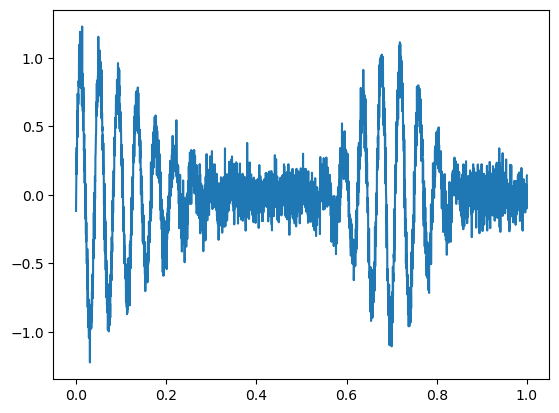

In [3]:
plt.plot(time,signal)

In [4]:
# Prepare the data for wavelet transform
orig = signal.copy()
p_high, p_low = one.BG_removal(orig)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(p_high, ntap, window='tukey')

# Compute the wavelet transform
s0 = 2
s1 = 0.5 * nt
dj = 1/8
js = int(1/dj*np.log2(s1/s0))
cwt_result = transform.decompose1d(signal, dt, s0*dt, dj, js, opts={'param': 2*np.pi}, mode="scaled", dtype=np.complex128)

# Denoising
print('Noise floor:', noise_level)
wavy_stuff, denoised_cwt = one.denoise_1d(cwt_result,white_noise_level=4*noise_level)

Noise floor: 0.1


In [13]:
WAS        = np.abs(denoised_cwt['decomposition'])
median_WAS = np.median(WAS, axis=(1), keepdims=True)
abs_dev    = np.abs(WAS - median_WAS)
sMAD_WAS   = 1.4826 * np.median(abs_dev, axis=(1), keepdims=True)
sMAD_WAS[sMAD_WAS == 0] = np.finfo(WAS.dtype).eps
WAS_normed = (WAS - median_WAS) / sMAD_WAS

original noise 0.10111564284863876
derived noise 0.10031477645287998


Text(0.5, 0, 'Time')

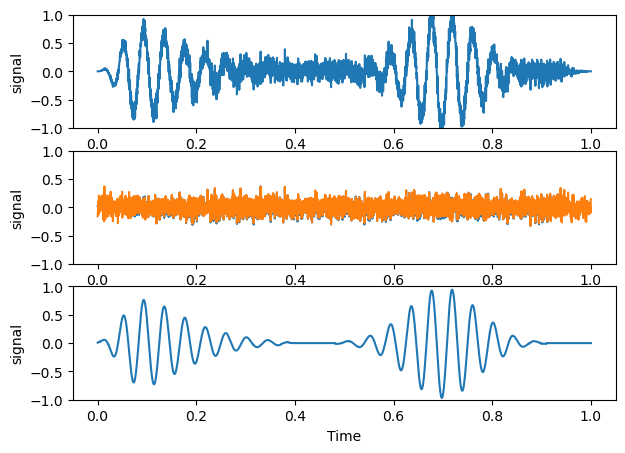

In [6]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
ax1.plot(time,signal)
ax2 = fig.add_subplot(312)
ax2.plot(time,p_low+signal-wavy_stuff+np.mean(signal))
print('original noise', np.std(noise))
print('derived noise', np.std(signal[360:-360]-wavy_stuff[360:-360]))
ax2.plot(time,noise)
ax3 = fig.add_subplot(313)
ax3.plot(time,wavy_stuff)
ax1.set_ylim([-1,1])
ax2.set_ylim([-1,1])
ax3.set_ylim([-1,1])

ax1.set_ylabel('signal')
ax2.set_ylabel('signal')
ax3.set_ylabel('signal')
ax3.set_xlabel('Time')